# Importación de datos

In [1]:

import pandas as pd
datos = pd.read_json('https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
datos

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## Conversión de datos

In [2]:
datos['Churn'] = datos['Churn'].replace('', 'No')


In [3]:
columnas = ['customer', 'phone', 'internet', 'account']

for col in columnas:
    datos_expandidos = pd.json_normalize(datos[col])
    datos_expandidos.columns = [f"{col}_{c}" for c in datos_expandidos.columns]
    datos = pd.concat([datos, datos_expandidos], axis=1)
    datos = datos.drop(columns=[col])

if 'account_Charges' in datos.columns:
    cargos_expandidos = pd.json_normalize(datos['account_Charges'])
    cargos_expandidos.columns = [f"account_Charges_{c}" for c in cargos_expandidos.columns]
    datos = pd.concat([datos, cargos_expandidos], axis=1)
    datos = datos.drop(columns=['account_Charges'])

datos.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
datos

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


# 🛠️ Preparación de los Datos

##Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [5]:
X = datos.drop(columns=['customerID'])
y = datos['Churn']

## Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

### Visualizando componentes de cada variable

In [6]:
print("Visualizando opciones para cada variable:")
for col in datos.columns:
    print(f"--- Columna: {col} ---")
    if datos[col].dtype == 'object' or datos[col].nunique() <= 20: # Display unique values for object type or low cardinality numerical
        print(datos[col].value_counts(dropna=False))
    else: # For high cardinality numerical columns
        print(f"Tipo de dato: {datos[col].dtype}")
        print(f"Número de valores únicos: {datos[col].nunique()}")
        print(f"Ejemplo de valores: {datos[col].unique()[:5]}") # Show first 5 unique values
    print("\n")

Visualizando opciones para cada variable:
--- Columna: customerID ---
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64


--- Columna: Churn ---
Churn
No     5398
Yes    1869
Name: count, dtype: int64


--- Columna: customer_gender ---
customer_gender
Male      3675
Female    3592
Name: count, dtype: int64


--- Columna: customer_SeniorCitizen ---
customer_SeniorCitizen
0    6085
1    1182
Name: count, dtype: int64


--- Columna: customer_Partner ---
customer_Partner
No     3749
Yes    3518
Name: count, dtype: int64


--- Columna: customer_Dependents ---
customer_Dependents
No     5086
Yes    2181
Name: count, dtype: int64


--- Columna: customer_tenure ---
Tipo de dato: int64
Número de valores únicos: 73
Ejemplo de valores: [ 9  4 13  3 71]


--- Columna: phone_PhoneService ---
phone_PhoneService
Yes    6560
No

In [7]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [8]:
columnas = X.columns

In [9]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),
                                   ['Churn', 'customer_gender', 'phone_PhoneService', 'phone_MultipleLines','internet_InternetService','internet_OnlineSecurity',
                                    'internet_OnlineBackup','internet_DeviceProtection','internet_TechSupport','internet_StreamingTV',
                                    'internet_StreamingMovies','account_Contract', 'account_PaperlessBilling','account_PaymentMethod',
                                    'customer_SeniorCitizen',	'customer_Partner',	'customer_Dependents']),
                                  remainder= 'passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [10]:
X = one_hot.fit_transform(X)

In [11]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__Churn_Yes', 'onehotencoder__customer_gender_Male',
       'onehotencoder__phone_PhoneService_Yes',
       'onehotencoder__phone_MultipleLines_No',
       'onehotencoder__phone_MultipleLines_No phone service',
       'onehotencoder__phone_MultipleLines_Yes',
       'onehotencoder__internet_InternetService_DSL',
       'onehotencoder__internet_InternetService_Fiber optic',
       'onehotencoder__internet_InternetService_No',
       'onehotencoder__internet_OnlineSecurity_No',
       'onehotencoder__internet_OnlineSecurity_No internet service',
       'onehotencoder__internet_OnlineSecurity_Yes',
       'onehotencoder__internet_OnlineBackup_No',
       'onehotencoder__internet_OnlineBackup_No internet service',
       'onehotencoder__internet_OnlineBackup_Yes',
       'onehotencoder__internet_DeviceProtection_No',
       'onehotencoder__internet_DeviceProtection_No internet service',
       'onehotencoder__internet_DeviceProtection_Yes',
       'onehotencoder__inter

In [12]:
X

array([[0.0, 0.0, 1.0, ..., 9, 65.6, '593.3'],
       [0.0, 1.0, 1.0, ..., 9, 59.9, '542.4'],
       [1.0, 1.0, 1.0, ..., 4, 73.9, '280.85'],
       ...,
       [0.0, 1.0, 1.0, ..., 2, 50.3, '92.75'],
       [0.0, 1.0, 1.0, ..., 67, 67.85, '4627.65'],
       [0.0, 1.0, 0.0, ..., 63, 59.0, '3707.6']], dtype=object)

In [13]:
pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas))

,onehotencoder__Churn_Yes,onehotencoder__customer_gender_Male,onehotencoder__phone_PhoneService_Yes,onehotencoder__phone_MultipleLines_No,onehotencoder__phone_MultipleLines_No phone service,onehotencoder__phone_MultipleLines_Yes,onehotencoder__internet_InternetService_DSL,onehotencoder__internet_InternetService_Fiber optic,onehotencoder__internet_InternetService_No,onehotencoder__internet_OnlineSecurity_No,...,onehotencoder__account_PaymentMethod_Bank transfer (automatic),onehotencoder__account_PaymentMethod_Credit card (automatic),onehotencoder__account_PaymentMethod_Electronic check,onehotencoder__account_PaymentMethod_Mailed check,onehotencoder__customer_SeniorCitizen_1,onehotencoder__customer_Partner_Yes,onehotencoder__customer_Dependents_Yes,remainder__customer_tenure,remainder__account_Charges.Monthly,remainder__account_Charges.Total
0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,9,65.6,593.3
1,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,9,59.9,542.4
2,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4,73.9,280.85
3,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,13,98.0,1237.85
4,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3,83.9,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13,55.15,742.9
7263,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,22,85.1,1873.7
7264,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2,50.3,92.75
7265,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,67,67.85,4627.65


In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
label_encoder = LabelEncoder()

In [16]:
y = label_encoder.fit_transform(y)

In [17]:
y

array([0, 0, 1, ..., 0, 0, 0])

## Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [18]:
churn_counts = pd.Series(y).value_counts()
churn_proportions = pd.Series(y).value_counts(normalize=True)

print("Conteo de clientes que cancelaron (1) vs. los que no (0):")
print(churn_counts)
print("\nProporción de clientes que cancelaron (1) vs. los que no (0):")
print(churn_proportions)

Conteo de clientes que cancelaron (1) vs. los que no (0):
0    5398
1    1869
Name: count, dtype: int64

Proporción de clientes que cancelaron (1) vs. los que no (0):
0    0.74281
1    0.25719
Name: proportion, dtype: float64


## Balanceo de Clases (opcional)

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
Artículo en Alura sobre desbalanceo de datos

In [27]:
from imblearn.over_sampling import SMOTE

feature_names = one_hot.get_feature_names_out(columnas)

X_df = pd.DataFrame(X, columns=feature_names)

X_df['remainder__account_Charges.Total'] = pd.to_numeric(X_df['remainder__account_Charges.Total'], errors='coerce')

X_df['remainder__account_Charges.Total'] = X_df['remainder__account_Charges.Total'].fillna(0)

X_processed = X_df.values

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_processed, y)

print("Shape of X before SMOTE:", X.shape)
print("Shape of X after SMOTE:", X_resampled.shape)
print("\nClass distribution of y before SMOTE:", pd.Series(y).value_counts())
print("Class distribution of y after SMOTE:", pd.Series(y_resampled).value_counts())

Shape of X before SMOTE: (7267, 41)
Shape of X after SMOTE: (10796, 41)

Class distribution of y before SMOTE: 0    5398
1    1869
Name: count, dtype: int64
Class distribution of y after SMOTE: 0    5398
1    5398
Name: count, dtype: int64


## Normalización o Estandarización (si es necesario)

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:
Artículo en Medium sobre normalización y estandarización en Machine Learning

# Correlación y Selección de Variables



## Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

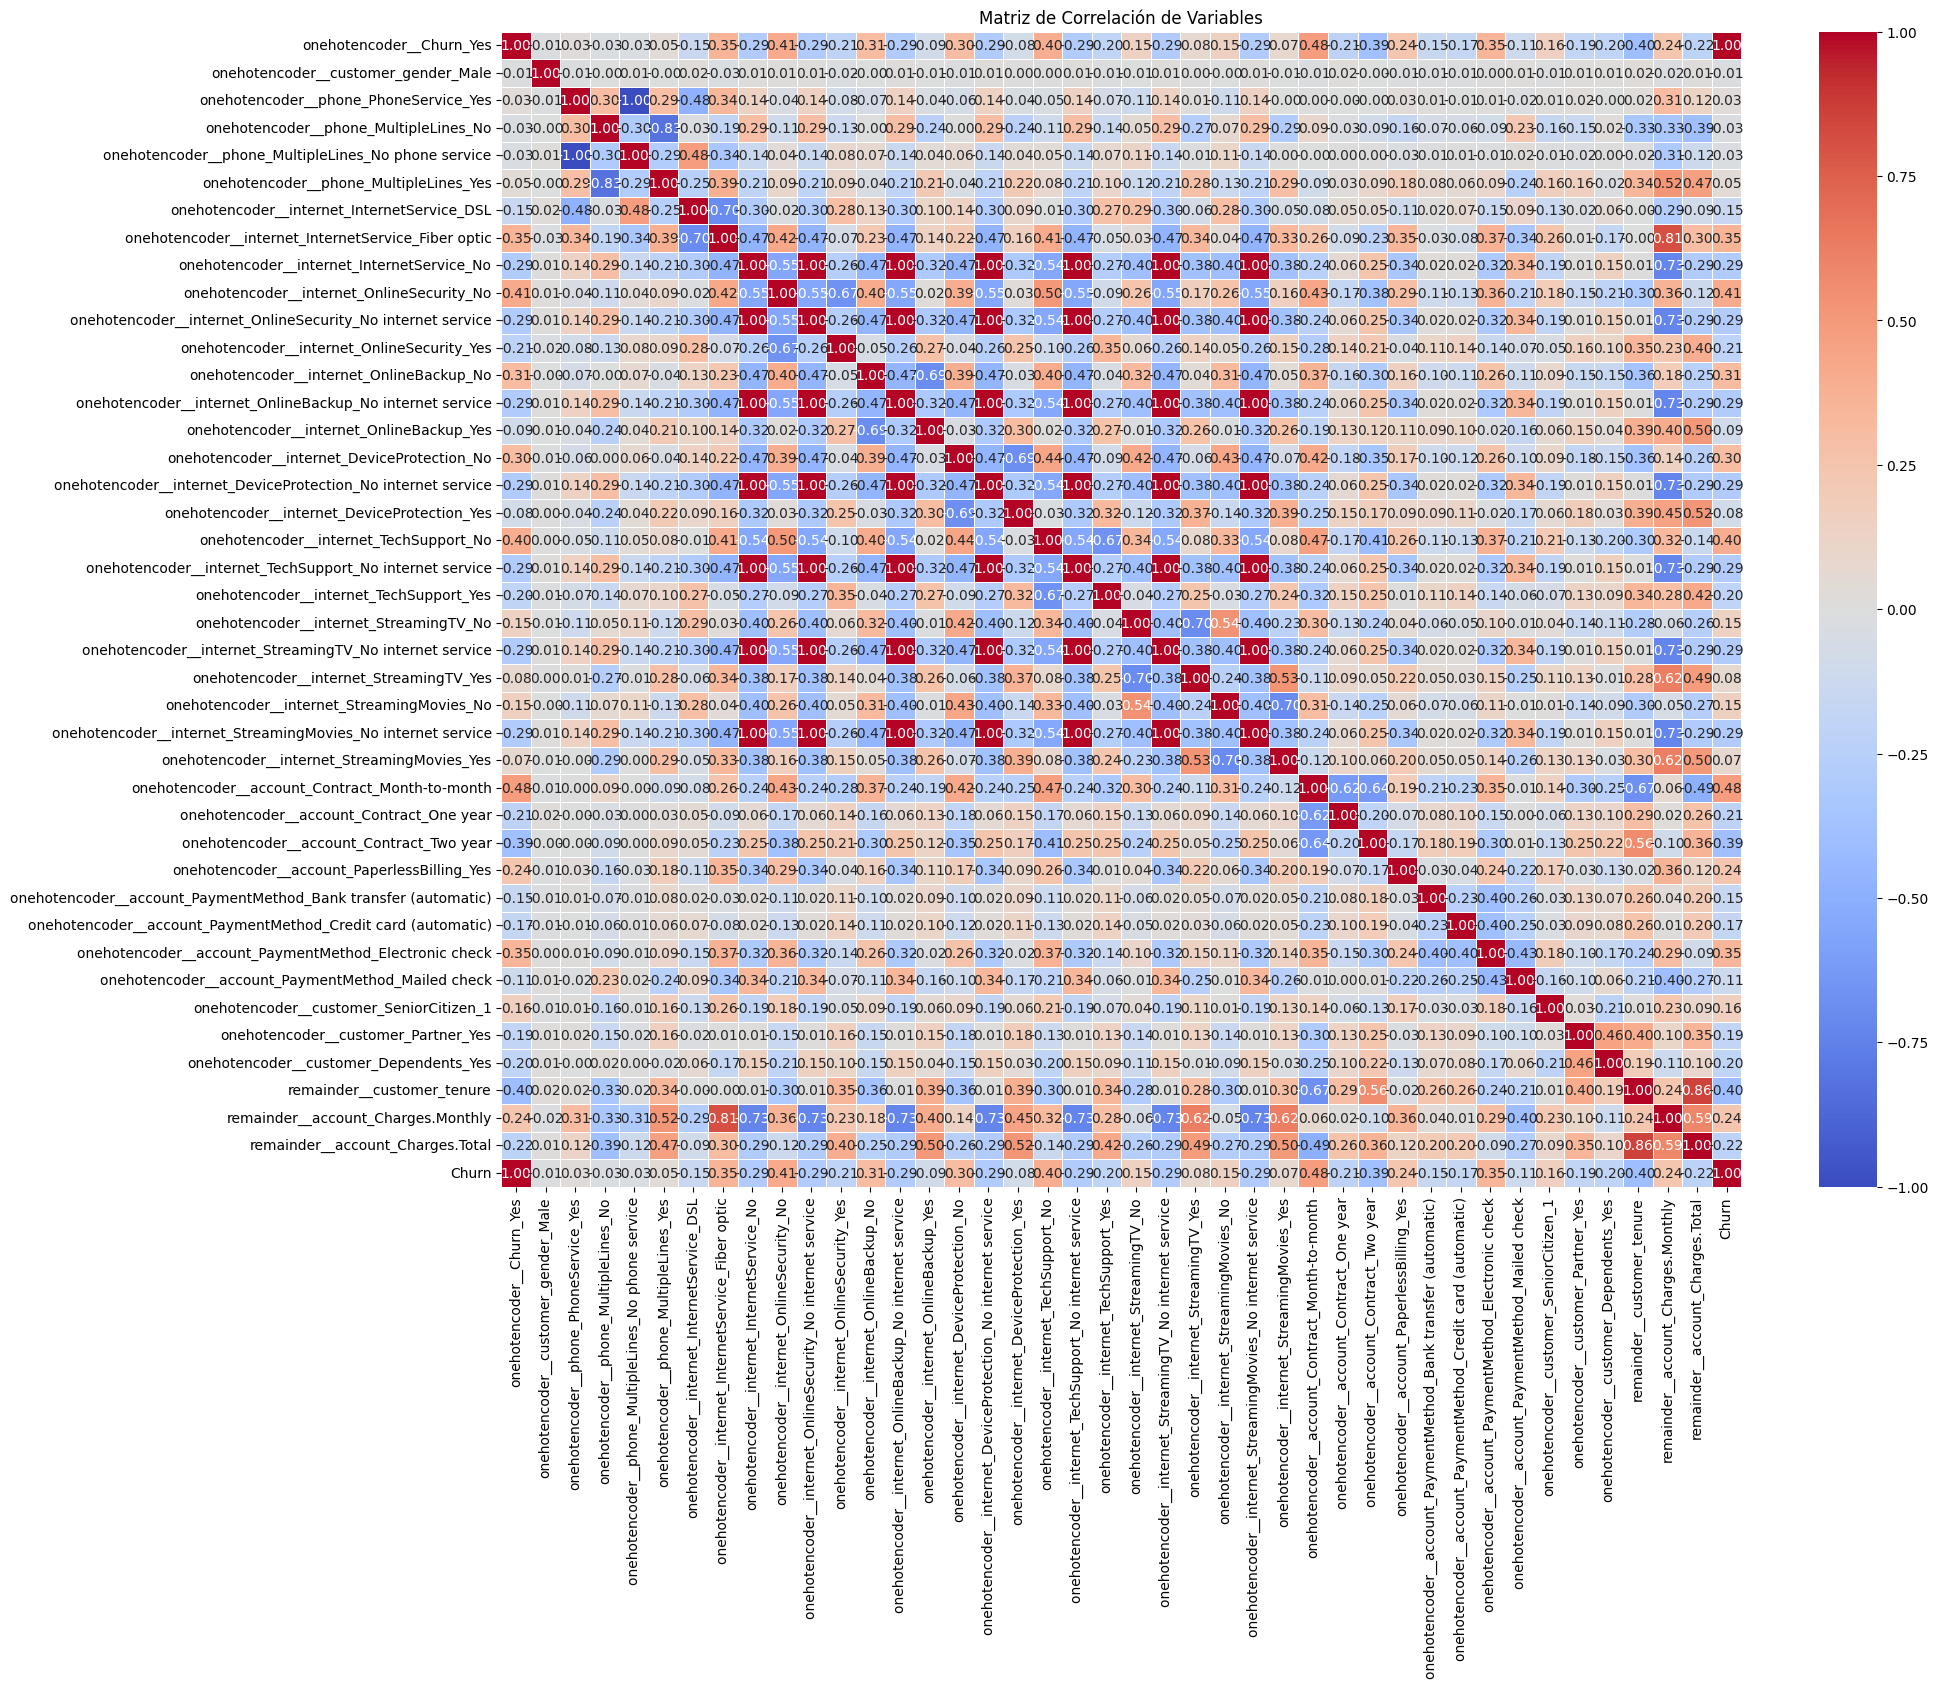

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = one_hot.get_feature_names_out(columnas)
data_for_corr = pd.DataFrame(X_resampled, columns=feature_names)
data_for_corr['Churn'] = y_resampled

corr_matrix = data_for_corr.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

## Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.


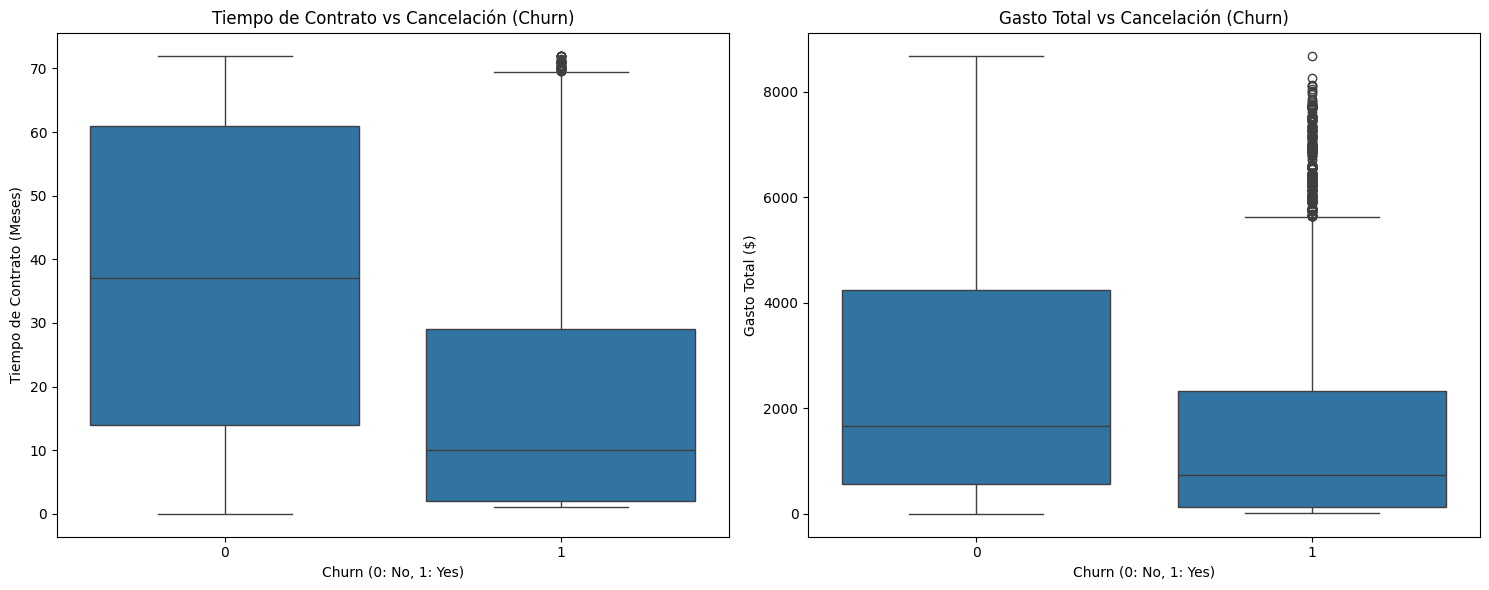

In [30]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='remainder__customer_tenure', data=data_for_corr)
plt.title('Tiempo de Contrato vs Cancelación (Churn)')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Tiempo de Contrato (Meses)')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='remainder__account_Charges.Total', data=data_for_corr)
plt.title('Gasto Total vs Cancelación (Churn)')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

## Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)


## Creación de Modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_scaled, y_train)

y_pred_log_reg = log_reg_model.predict(X_test_scaled)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"Regresión Logística / KNN:: {accuracy_log_reg:.4f}")

Regresión Logística / KNN:: 1.0000


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Árbol de Decisión / Random Forest: {accuracy_rf:.4f}")

Árbol de Decisión / Random Forest: 1.0000


## Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.


--- Evaluación del Modelo de Regresión Logística ---
Accuracy: 1.0000

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1080
           1       1.00      1.00      1.00      1080

    accuracy                           1.00      2160
   macro avg       1.00      1.00      1.00      2160
weighted avg       1.00      1.00      1.00      2160



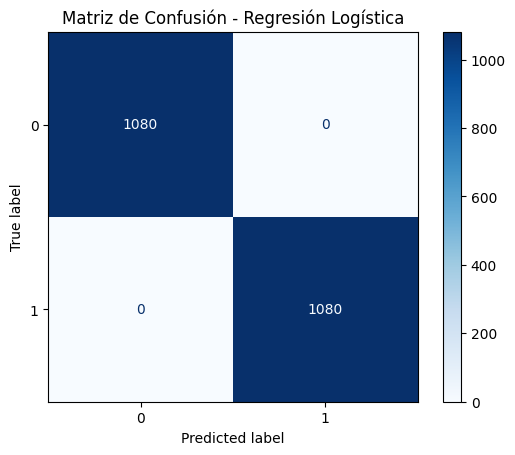


--- Evaluación del Modelo Random Forest ---
Accuracy: 1.0000

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1080
           1       1.00      1.00      1.00      1080

    accuracy                           1.00      2160
   macro avg       1.00      1.00      1.00      2160
weighted avg       1.00      1.00      1.00      2160



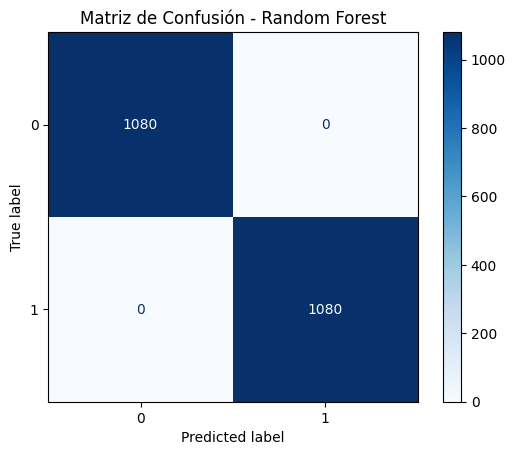

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n--- Evaluación del Modelo de Regresión Logística ---")
print("Accuracy: {:.4f}".format(accuracy_log_reg))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_log_reg))

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

print("\n--- Evaluación del Modelo Random Forest ---")
print("Accuracy: {:.4f}".format(accuracy_rf))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Random Forest')
plt.show()